In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Setting Up Environment/venv

In [ ]:
!wget -q https://repo.anaconda.com/miniconda/Miniconda3-py38_23.11.0-2-Linux-x86_64.sh -O /tmp/miniconda.sh
!bash /tmp/miniconda.sh -b -p /opt/miniconda3

In [ ]:
!/opt/miniconda3/bin/conda create -n bevfusion python=3.8 -y
!/opt/miniconda3/envs/bevfusion/bin/pip install torch==1.10.2+cu113 torchvision==0.11.3+cu113 torchaudio==0.10.2 -f https://download.pytorch.org/whl/torch_stable.html
!/opt/miniconda3/envs/bevfusion/bin/python -c "import torch; print(torch.__version__)"

## CUDA toolkit + gcc (needed BEFORE compiling BEVFusion's custom ops later)
Moved up here, right after torch, so everything is ready by the time we
reach `setup.py develop` — no more building mmdetection3d first and
discovering the toolkit/gcc are missing partway through.

In [ ]:
!/opt/miniconda3/bin/conda install -n bevfusion -y -c nvidia/label/cuda-11.3.1 cuda-toolkit

In [ ]:
!/opt/miniconda3/bin/conda install -n bevfusion -y -c conda-forge gcc_linux-64=9 gxx_linux-64=9

In [ ]:
!/opt/miniconda3/bin/conda install -n bevfusion -y -c conda-forge libxcrypt

In [ ]:
# # Confirm the exact compiler binary names conda-forge installed before wiring
# # them into CC/CXX below.
!ls /opt/miniconda3/envs/bevfusion/bin/ | grep gcc

In [ ]:
# # Persist these for the rest of the session (must be re-run after any kernel restart).
# import os
# os.environ["CUDA_HOME"] = "/opt/miniconda3/envs/bevfusion"
# os.environ["PATH"] = "/opt/miniconda3/envs/bevfusion/bin:" + os.environ["PATH"]
# # TODO: update these two filenames to exactly match the `ls | grep gcc` output above
# os.environ["CC"] = "/opt/miniconda3/envs/bevfusion/bin/x86_64-conda_cos6-linux-gnu-gcc"
# os.environ["CXX"] = "/opt/miniconda3/envs/bevfusion/bin/x86_64-conda_cos6-linux-gnu-g++"

In [ ]:
# Persist these for the rest of the session
# Re-run after any kernel restart.

import os

ENV = "/opt/miniconda3/envs/bevfusion"

os.environ["CUDA_HOME"] = ENV
os.environ["PATH"] = f"{ENV}/bin:" + os.environ["PATH"]

# Conda GCC 9 / G++ 9
os.environ["CC"] = f"{ENV}/bin/x86_64-conda-linux-gnu-gcc"
os.environ["CXX"] = f"{ENV}/bin/x86_64-conda-linux-gnu-g++"
os.environ["CUDAHOSTCXX"] = os.environ["CXX"]

# System include/library paths needed during compilation
os.environ["CFLAGS"] = "-isystem /usr/include"
os.environ["CXXFLAGS"] = "-isystem /usr/include"
os.environ["LDFLAGS"] = (
    "-L/usr/lib/x86_64-linux-gnu "
    "-L/lib/x86_64-linux-gnu "
    "-L/usr/lib "
    "-L/lib"
)

In [ ]:
# Both should now report versions from the env (11.3 and 9.x), not Kaggle's
# system defaults (12.8 / newer gcc).
!nvcc --version
!$CC --version

In [ ]:
!/opt/miniconda3/envs/bevfusion/bin/pip install -U openmim

In [ ]:
!/opt/miniconda3/envs/bevfusion/bin/mim install mmengine

In [ ]:
!/opt/miniconda3/envs/bevfusion/bin/mim install "mmcv==2.1.0"
!/opt/miniconda3/envs/bevfusion/bin/mim install "mmdet>=3.0.0"

In [ ]:
!/opt/miniconda3/envs/bevfusion/bin/python -c "import mmcv, mmdet; print('mmcv', mmcv.__version__); print('mmdet', mmdet.__version__)"

# Setting up mmdetection3d

In [ ]:
!git clone https://github.com/open-mmlab/mmdetection3d.git -b dev-1.x

In [ ]:
%cd mmdetection3d

In [ ]:
!/opt/miniconda3/envs/bevfusion/bin/pip install -v -e .

In [ ]:
!/opt/miniconda3/envs/bevfusion/bin/pip install cumm-cu113
!/opt/miniconda3/envs/bevfusion/bin/pip install spconv-cu113

In [ ]:
!/opt/miniconda3/envs/bevfusion/bin/mim download mmdet3d --config pointpillars_hv_secfpn_8xb6-160e_kitti-3d-car --dest .

**Verifying installation**

In [ ]:
!/opt/miniconda3/envs/bevfusion/bin/python demo/pcd_demo.py demo/data/kitti/000008.bin pointpillars_hv_secfpn_8xb6-160e_kitti-3d-car.py hv_pointpillars_secfpn_6x8_160e_kitti-3d-car_20220331_134606-d42d15ed.pth

# Setting up BEV-Fusion
CUDA toolkit and gcc were already installed and wired up earlier, so this
should now compile cleanly on the first try.

In [ ]:
%cd projects/BEVFusion

In [ ]:
!ls
# !cat README.md

In [ ]:
%cd ../..

In [ ]:
# !/opt/miniconda3/bin/conda install -n bevfusion -y -c conda-forge libxcrypt

In [ ]:
!{ENV}/bin/x86_64-conda-linux-gnu-gcc --version
!{ENV}/bin/x86_64-conda-linux-gnu-g++ --version

In [ ]:
!test -x {ENV}/bin/x86_64-conda-linux-gnu-gcc && echo "GCC found"
!test -x {ENV}/bin/x86_64-conda-linux-gnu-g++ && echo "G++ found"

In [ ]:
print("CUDA_HOME:", os.environ["CUDA_HOME"])
print("CC:", os.environ["CC"])
print("CXX:", os.environ["CXX"])
print("CUDAHOSTCXX:", os.environ["CUDAHOSTCXX"])
print("CFLAGS:", os.environ["CFLAGS"])
print("CXXFLAGS:", os.environ["CXXFLAGS"])
print("LDFLAGS:", os.environ["LDFLAGS"])

In [ ]:
!/opt/miniconda3/envs/bevfusion/bin/python -c "import torch; print('PyTorch:', torch.__version__); print('CUDA:', torch.version.cuda); print('CUDA available:', torch.cuda.is_available())"

# BEV Inference

In [49]:
!find /kaggle/working/mmdetection3d/demo/data/nuscenes \
  -maxdepth 3 -type f | sort

/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_BACK__1532402927637525.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_BACK_LEFT__1532402927647423.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_BACK_RIGHT__1532402927627893.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_FRONT_LEFT__1532402927604844.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__CAM_FRONT_RIGHT__1532402927620339.jpg
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin
/kaggle/working/mmdetection3d/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800.pkl


In [51]:
import pickle

pkl_path = (
    "/kaggle/working/mmdetection3d/demo/data/nuscenes/"
    "n015-2018-07-24-11-22-45+0800.pkl"
)

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

print("Type:", type(data))

if isinstance(data, dict):
    print("Keys:", data.keys())
    for key, value in data.items():
        print(f"{key}: {type(value)}")
else:
    print("Length:", len(data))
    if len(data) > 0:
        print("First item type:", type(data[0]))
        print("First item:", data[0])

Type: <class 'dict'>
Keys: dict_keys(['metainfo', 'data_list'])
metainfo: <class 'dict'>
data_list: <class 'list'>


In [52]:
!wget -O /kaggle/working/bevfusion_lidar-cam.pth \
"https://download.openmmlab.com/mmdetection3d/v1.1.0_models/bevfusion/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d-5239b1af.pth"

--2026-09-17 19:41:13--  https://download.openmmlab.com/mmdetection3d/v1.1.0_models/bevfusion/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d-5239b1af.pth
Resolving download.openmmlab.com (download.openmmlab.com)... 163.181.60.201, 163.181.60.204, 163.181.60.208, ...
Connecting to download.openmmlab.com (download.openmmlab.com)|163.181.60.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 167113973 (159M) [application/octet-stream]
Saving to: ‘/kaggle/working/bevfusion_lidar-cam.pth’

/kaggle/working/bev 100%[===================>] 159.37M  5.17MB/s    in 32s     

2026-09-17 19:41:46 (4.91 MB/s) - ‘/kaggle/working/bevfusion_lidar-cam.pth’ saved [167113973/167113973]



In [58]:
ENV = "/opt/miniconda3/envs/bevfusion"
ROOT = "/kaggle/working/mmdetection3d"

OUT = "/kaggle/working/bevfusion_result.png"

!{ENV}/bin/python {ROOT}/projects/BEVFusion/demo/multi_modality_demo.py \
{ROOT}/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin \
{ROOT}/demo/data/nuscenes/ \
{ROOT}/demo/data/nuscenes/n015-2018-07-24-11-22-45+0800.pkl \
{ROOT}/projects/BEVFusion/configs/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py \
/kaggle/working/bevfusion_lidar-cam.pth \
--cam-type all \
--score-thr 0.2 \
--out-dir {OUT}

/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:17: UserWarning: ``build_sampler`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_sampler`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/mmdet/models/task_modules/builder.py:39: UserWarning: ``build_assigner`` would be deprecated soon, please use ``mmdet.registry.TASK_UTILS.build()`` 
  warnings.warn('``build_assigner`` would be deprecated soon, please use '
/opt/miniconda3/envs/bevfusion/lib/python3.8/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
09/17 19:46:10 - mmengine - INFO - Loads checkpoint by http backend from path: https://github.com/SwinTr

Exists: True


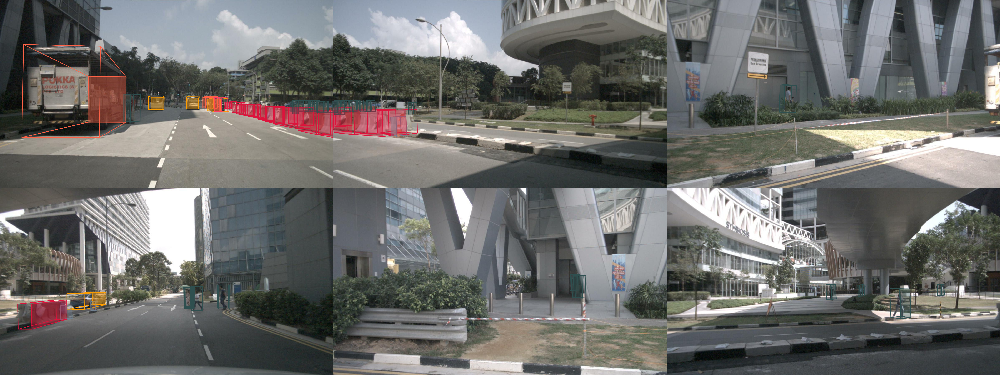

In [59]:
import os
from IPython.display import display, Image

print("Exists:", os.path.exists(OUT))

if os.path.exists(OUT):
    display(Image(filename=OUT))

In [57]:
! /opt/miniconda3/envs/bevfusion/bin/python \
/kaggle/working/mmdetection3d/projects/BEVFusion/demo/multi_modality_demo.py \
--help

! grep -nE "show|out|save|visual|draw" \
/kaggle/working/mmdetection3d/projects/BEVFusion/demo/multi_modality_demo.py

usage: multi_modality_demo.py [-h] [--device DEVICE] [--cam-type CAM_TYPE]
                              [--score-thr SCORE_THR] [--out-dir OUT_DIR]
                              [--show] [--snapshot]
                              pcd img ann config checkpoint

positional arguments:
  pcd                   Point cloud file
  img                   image file
  ann                   ann file
  config                Config file
  checkpoint            Checkpoint file

optional arguments:
  -h, --help            show this help message and exit
  --device DEVICE       Device used for inference
  --cam-type CAM_TYPE   choose camera type to inference
  --score-thr SCORE_THR
                        bbox score threshold
  --out-dir OUT_DIR     dir to save results
  --show                show online visualization results
  --snapshot            whether to save online visualization results
27:        '--out-dir', type=str, default='demo', help='dir to save results')
29:        '--show',
31:      